Daniel Simple Moving Avg:

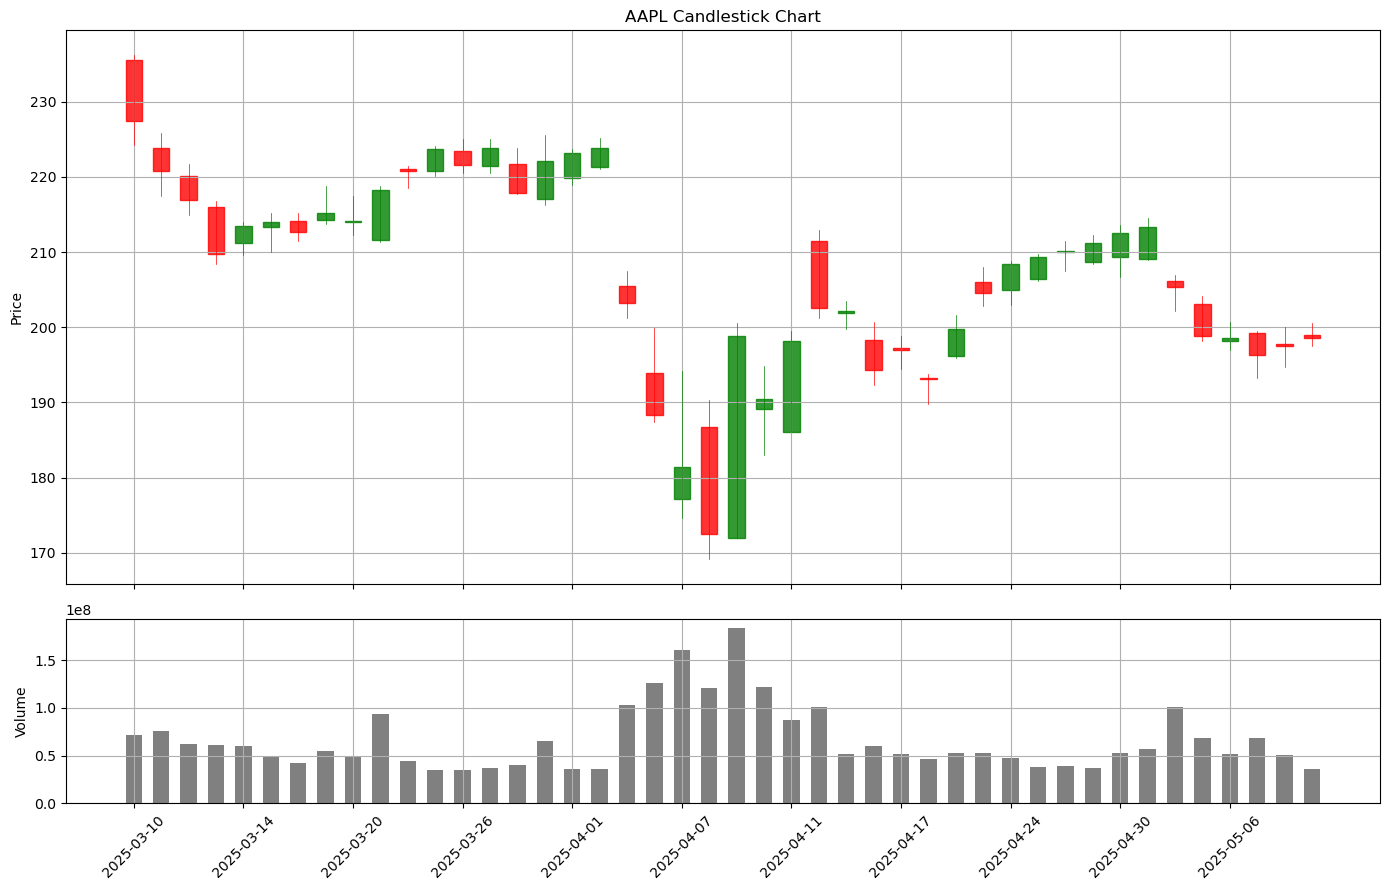

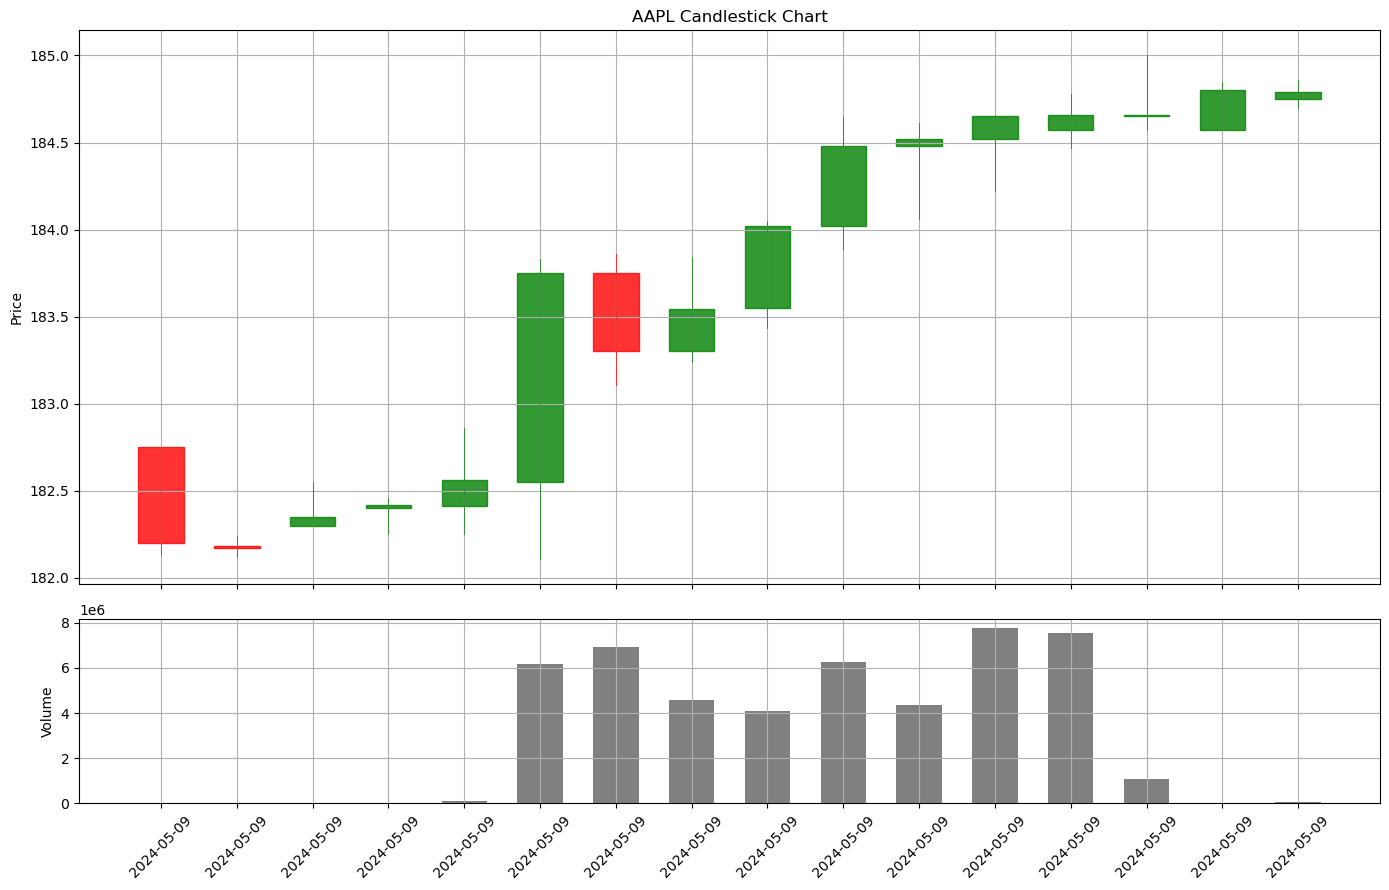

In [ ]:
import pandas as pd
#from Get_stock_data import get_stock_data #has to be imported from the same directory and a .py file
%run get_stock_data.ipynb


In [22]:
def SimpleMA(df, small_window=20, long_window=50):
    result = df[['close']].copy()  # keep close column
    result['signal'] = 0

    sma = df['close'].rolling(window=small_window).mean()
    lma = df['close'].rolling(window=long_window).mean()

    result.loc[sma > lma, 'signal'] = 1
    result.loc[sma < lma, 'signal'] = -1

    return result  # ✅ returns full DataFrame with 'close' and 'signal'


In [23]:
df = get_stock_data("AAPL", "2024-05-01", "2024-05-10", "Minute", 1)
a = SimpleMA(df)
print(a)


                                   close  signal
symbol timestamp                                
AAPL   2024-05-01 08:00:00+00:00  170.20       0
       2024-05-01 08:01:00+00:00  170.00       0
       2024-05-01 08:02:00+00:00  170.00       0
       2024-05-01 08:05:00+00:00  169.90       0
       2024-05-01 08:07:00+00:00  169.90       0
...                                  ...     ...
       2024-05-09 23:52:00+00:00  184.74      -1
       2024-05-09 23:53:00+00:00  184.79      -1
       2024-05-09 23:54:00+00:00  184.74      -1
       2024-05-09 23:55:00+00:00  184.73      -1
       2024-05-09 23:56:00+00:00  184.79       1

[5559 rows x 2 columns]


In [27]:
def backtest(data, initial_cash=10_000, transaction_cost=0):
    in_position = False
    cash = initial_cash
    entry_price = 0
    trade_log = []
    equity_curve = []

    for i in range(1, len(data)):
        signal = data['signal'].iloc[i]
        price = data['close'].iloc[i]
        timestamp = data.index[i]

        # Track equity at each time step
        equity_curve.append((timestamp, cash))

        if signal == 1 and not in_position:
            entry_price = price
            in_position = True
            trade_log.append({
                'timestamp': timestamp,
                'action': 'buy',
                'price': price
            })

        elif signal == -1 and in_position:
            pnl = price - entry_price
            cash += pnl
            in_position = False
            trade_log.append({
                'timestamp': timestamp,
                'action': 'sell',
                'price': price,
                'pnl': pnl,
                'cash': cash
            })

    # Final equity entry
    if len(data) > 0:
        equity_curve.append((data.index[-1], cash))

    # Convert to pandas Series
    index = [ts[1] if isinstance(ts, tuple) else ts for (ts, _) in equity_curve]
    equity_series = pd.Series(
        data=[val for (_, val) in equity_curve],
        index=pd.to_datetime(index)
    )

    return equity_series, trade_log


In [25]:
def plot_equity_curve(equity_series):
    plt.figure(figsize=(12, 6))
    plt.plot(equity_series, label='Equity Curve', linewidth=2)
    plt.title("Strategy Equity Curve")
    plt.xlabel("Time")
    plt.ylabel("Cash / Equity")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


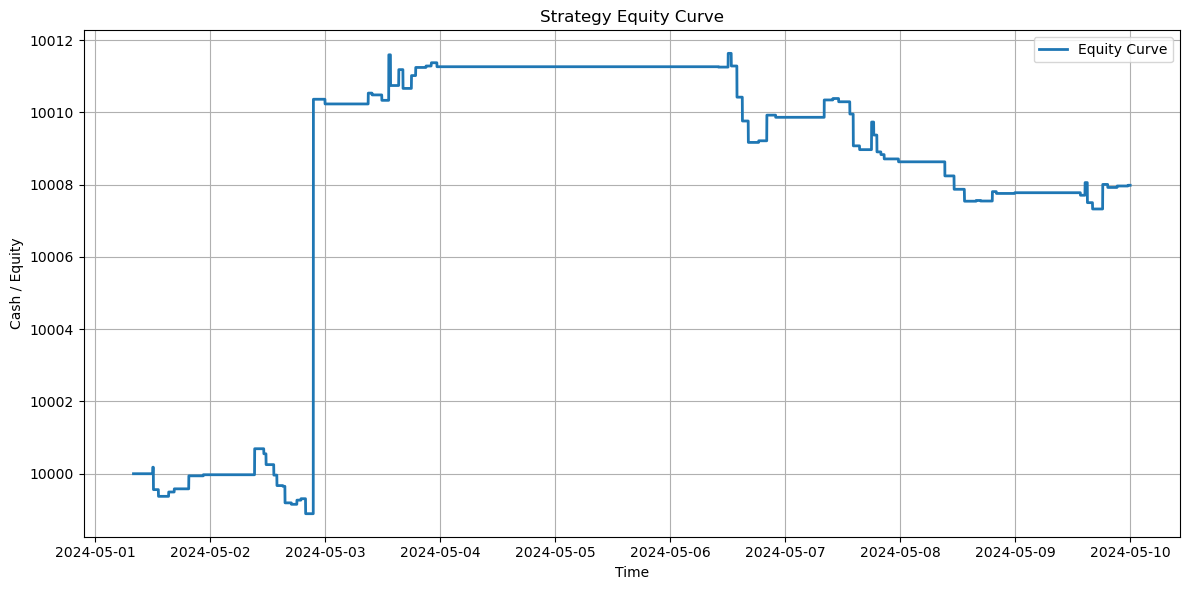

In [28]:
df = get_stock_data("AAPL", "2024-05-01", "2024-05-10", "Minute", 1)
signals = SimpleMA(df)
equity_series, trades = backtest(signals)
plot_equity_curve(equity_series)
